# Measuring Retrieval Quality

How do we know if a retrieval system is good? This demo walks through the
standard metrics, from simple precision/recall on unranked sets to nDCG with
graded relevance, using two contrasting retrieval systems on our library
collection.

**Learning goals:**
- Compute precision and recall from a retrieved set vs. ground truth
- Understand the precision-recall trade-off and how F-beta mediates it
- Compute ranked metrics (P@k, reciprocal rank, AP) and understand what each rewards
- Build interpolated precision-recall curves
- Compute nDCG with graded relevance judgments
- Compare systems using MAP and nDCG

**Prerequisites:** Chapter 1 (retrieval models, ranked results)

In [1]:
from shared.library_collection import (
    LIBRARY, NEED, GRADES, RUNS, NEEDS,
    record, grade, is_relevant, relevant_ids, run, need_text, grades, need_ids
)
from shared.display import print_table, display_md
from shared.plot import plot_pr_curve
import math
import matplotlib.pyplot as plt

## The Scenario

We have a university library of 50 books and a student with an information need:
*"Which books give a beginning master's student solid computer science
foundations?"* Two retrieval systems returned ranked lists. System A goes broad
(25 results), System B is selective (8 results). Which system is better?

In [2]:
# The information need and ground truth
rel = set(relevant_ids())
display_md(
    f"**Information need:** {NEED}\n\n"
    f"**Relevant books:** {len(rel)} out of {len(LIBRARY)} in the collection\n\n"
    f"**System A** returned {len(run('cs-foundations', 'A'))} results\n\n"
    f"**System B** returned {len(run('cs-foundations', 'B'))} results"
)

**Information need:** Which books give a beginning master's student solid computer science foundations?

**Relevant books:** 15 out of 50 in the collection

**System A** returned 25 results

**System B** returned 8 results

---
## 1. Unranked Evaluation: Precision and Recall

Before we look at rankings, let us treat each system's result list as a plain
**set** of documents. Precision asks: "of what we retrieved, how much is
relevant?" Recall asks: "of what is relevant, how much did we retrieve?"

In [3]:
# Treat result lists as unranked sets
retrieved_a = set(run("cs-foundations", "A"))
retrieved_b = set(run("cs-foundations", "B"))

# True positives, false positives, false negatives
tp_a = retrieved_a & rel
fp_a = retrieved_a - rel
fn_a = rel - retrieved_a

tp_b = retrieved_b & rel
fp_b = retrieved_b - rel
fn_b = rel - retrieved_b

print_table(
    [
        ["System A", len(tp_a), len(fp_a), len(fn_a), len(retrieved_a), len(rel)],
        ["System B", len(tp_b), len(fp_b), len(fn_b), len(retrieved_b), len(rel)],
    ],
    headers=["System", "TP", "FP", "FN", "Retrieved", "Relevant"],
)

| System   |   TP |   FP |   FN |   Retrieved |   Relevant |
|:---------|-----:|-----:|-----:|------------:|-----------:|
| System A |   12 |   13 |    3 |          25 |         15 |
| System B |    6 |    2 |    9 |           8 |         15 |

In [4]:
# Precision and Recall
prec_a = len(tp_a) / len(retrieved_a)
rec_a = len(tp_a) / len(rel)

prec_b = len(tp_b) / len(retrieved_b)
rec_b = len(tp_b) / len(rel)

print_table(
    [
        ["System A", f"{prec_a:.3f}", f"{rec_a:.3f}"],
        ["System B", f"{prec_b:.3f}", f"{rec_b:.3f}"],
    ],
    headers=["System", "Precision", "Recall"],
)

| System   |   Precision |   Recall |
|:---------|------------:|---------:|
| System A |        0.48 |      0.8 |
| System B |        0.75 |      0.4 |

System A retrieves more relevant documents (higher recall) but pollutes its
results with irrelevant ones (lower precision). System B is cleaner but misses
many relevant books. This is the **precision-recall trade-off**.

### F-measure: Balancing Precision and Recall

The F-measure combines precision and recall into a single number. The parameter
beta controls the emphasis: beta < 1 favours precision, beta > 1 favours recall.

In [5]:
def f_measure(precision, recall, beta=1.0):
    """Compute F-beta score from precision and recall."""
    if precision + recall == 0:
        return 0.0
    beta_sq = beta ** 2
    return (1 + beta_sq) * precision * recall / (beta_sq * precision + recall)

# Compare at different beta values
rows = []
for beta in [0.5, 1.0, 2.0]:
    f_a = f_measure(prec_a, rec_a, beta)
    f_b = f_measure(prec_b, rec_b, beta)
    winner = "A" if f_a > f_b else "B"
    rows.append([f"F_{beta}", f"{f_a:.3f}", f"{f_b:.3f}", winner])

print_table(rows, headers=["Metric", "System A", "System B", "Winner"])

| Metric   |   System A |   System B | Winner   |
|:---------|-----------:|-----------:|:---------|
| F_0.5    |      0.522 |      0.638 | B        |
| F_1.0    |      0.6   |      0.522 | A        |
| F_2.0    |      0.706 |      0.441 | A        |

In [6]:
display_md(
    "**Interpretation:** When we value recall more (F_2), System A wins "
    "because it finds more relevant books. When we value precision more (F_0.5), "
    "System B wins because it returns fewer irrelevant results. "
    "F_1 gives equal weight to both."
)

**Interpretation:** When we value recall more (F_2), System A wins because it finds more relevant books. When we value precision more (F_0.5), System B wins because it returns fewer irrelevant results. F_1 gives equal weight to both.

---
## 2. Ranked Evaluation: P@k, Reciprocal Rank, and Average Precision

Unranked metrics ignore the order of results. But rank matters: a relevant
document at position 1 is far more useful than one at position 20. Ranked
metrics reward systems that place relevant documents early.

### Building a Relevance Table

In [7]:
# Show ranked results with relevance labels
run_a = run("cs-foundations", "A")

rows = []
for rank, doc_id in enumerate(run_a[:15], 1):
    title = record(doc_id)["title"]
    rel_grade = grade(doc_id)
    rel_label = "Yes" if rel_grade > 0 else ""
    rows.append([rank, doc_id, title[:45], rel_grade, rel_label])

print_table(rows, headers=["Rank", "ID", "Title", "Grade", "Relevant?"])

|   Rank | ID                    | Title                                         |   Grade | Relevant?   |
|-------:|:----------------------|:----------------------------------------------|--------:|:------------|
|      1 | computer-organization | Computer Organization and Design: The Hardwar |       1 | Yes         |
|      2 | operating-systems     | Operating System Concepts                     |       2 | Yes         |
|      3 | handmaids-tale        | The Handmaid's Tale                           |       0 |             |
|      4 | frederick-douglass    | Narrative of the Life of Frederick Douglass,  |       0 |             |
|      5 | new-architecture      | Towards a New Architecture                    |       0 |             |
|      6 | data-science-scratch  | Data Science from Scratch                     |       3 | Yes         |
|      7 | programming-languages | Concepts of Programming Languages             |       2 | Yes         |
|      8 | leaves-of-grass       | Leaves of Grass                               |       0 |             |
|      9 | ai-modern-approach    | Artificial Intelligence: A Modern Approach    |       2 | Yes         |
|     10 | ragtime               | Ragtime                                       |       0 |             |
|     11 | angels-in-america     | Angels in America                             |       0 |             |
|     12 | database-systems      | Database Systems: The Complete Book           |       3 | Yes         |
|     13 | theory-of-computation | Introduction to the Theory of Computation     |       2 | Yes         |
|     14 | madame-bovary         | Madame Bovary                                 |       0 |             |
|     15 | dracula               | Dracula                                       |       0 |             |

### Precision@k

P@k answers: "among the top k results, what fraction is relevant?"

In [8]:
def precision_at_k(ranked_list, k, need="cs-foundations"):
    """Precision at rank k."""
    top_k = ranked_list[:k]
    relevant_count = sum(1 for doc in top_k if is_relevant(doc, need))
    return relevant_count / k

# Compute P@k for System A and System B
rows = []
for k in [1, 3, 5, 10, 15, 20]:
    p_a = precision_at_k(run_a, k) if k <= len(run_a) else None
    p_b = precision_at_k(run("cs-foundations", "B"), k) if k <= len(run("cs-foundations", "B")) else None
    rows.append([
        k,
        f"{p_a:.3f}" if p_a is not None else "---",
        f"{p_b:.3f}" if p_b is not None else "---",
    ])

print_table(rows, headers=["k", "P@k (System A)", "P@k (System B)"])

|   k |   P@k (System A) | P@k (System B)   |
|----:|-----------------:|:-----------------|
|   1 |            1     | 1.000            |
|   3 |            0.667 | 1.000            |
|   5 |            0.4   | 0.800            |
|  10 |            0.5   | ---              |
|  15 |            0.467 | ---              |
|  20 |            0.45  | ---              |

### Reciprocal Rank

Reciprocal Rank answers: "how early is the first relevant result?"
RR = 1/rank of the first relevant document.

In [9]:
def reciprocal_rank(ranked_list, need="cs-foundations"):
    """Reciprocal rank: 1/position of first relevant document."""
    for rank, doc_id in enumerate(ranked_list, 1):
        if is_relevant(doc_id, need):
            return 1.0 / rank
    return 0.0

rr_a = reciprocal_rank(run_a)
rr_b = reciprocal_rank(run("cs-foundations", "B"))

display_md(
    f"| System | First relevant at rank | Reciprocal Rank |\n"
    f"|--------|----------------------|----------------|\n"
    f"| A | {1/rr_a:.0f} | {rr_a:.4f} |\n"
    f"| B | {1/rr_b:.0f} | {rr_b:.4f} |"
)

| System | First relevant at rank | Reciprocal Rank |
|--------|----------------------|----------------|
| A | 1 | 1.0000 |
| B | 1 | 1.0000 |

### Average Precision (AP)

AP rewards systems that place relevant documents at high ranks. It averages
precision values computed at each rank where a relevant document appears.

In [10]:
def average_precision(ranked_list, need="cs-foundations"):
    """Average Precision: mean of P@k at each relevant rank."""
    hits = 0
    sum_precision = 0.0
    for rank, doc_id in enumerate(ranked_list, 1):
        if is_relevant(doc_id, need):
            hits += 1
            sum_precision += hits / rank  # P@k at this rank
    total_relevant = len(relevant_ids(need))
    return sum_precision / total_relevant if total_relevant > 0 else 0.0

# Step-by-step computation for System A
run_a = run("cs-foundations", "A")
hits = 0
rows = []
for rank, doc_id in enumerate(run_a, 1):
    if is_relevant(doc_id):
        hits += 1
        p_at_k = hits / rank
        rows.append([rank, record(doc_id)["title"][:35], f"{hits}/{rank}", f"{p_at_k:.4f}"])

print_table(rows, headers=["Rank", "Title", "Hits/Rank", "P@k"])

|   Rank | Title                               | Hits/Rank   |    P@k |
|-------:|:------------------------------------|:------------|-------:|
|      1 | Computer Organization and Design: T | 1/1         | 1      |
|      2 | Operating System Concepts           | 2/2         | 1      |
|      6 | Data Science from Scratch           | 3/6         | 0.5    |
|      7 | Concepts of Programming Languages   | 4/7         | 0.5714 |
|      9 | Artificial Intelligence: A Modern A | 5/9         | 0.5556 |
|     12 | Database Systems: The Complete Book | 6/12        | 0.5    |
|     13 | Introduction to the Theory of Compu | 7/13        | 0.5385 |
|     16 | Structure and Interpretation of Com | 8/16        | 0.5    |
|     18 | Pattern Recognition and Machine Lea | 9/18        | 0.5    |
|     21 | Computer Systems: A Programmer's Pe | 10/21       | 0.4762 |
|     23 | Computer Networks                   | 11/23       | 0.4783 |
|     25 | Introduction to Algorithms          | 12/25       | 0.48   |

In [11]:
ap_a = average_precision(run_a)
ap_b = average_precision(run("cs-foundations", "B"))

display_md(
    f"**Average Precision:**\n\n"
    f"- System A: AP = {ap_a:.4f} (sum of P@k values / {len(relevant_ids())} relevant docs)\n"
    f"- System B: AP = {ap_b:.4f}\n\n"
    f"AP penalizes System A for scattering relevant documents "
    f"among irrelevant ones at high ranks."
)

**Average Precision:**

- System A: AP = 0.4733 (sum of P@k values / 15 relevant docs)
- System B: AP = 0.3589

AP penalizes System A for scattering relevant documents among irrelevant ones at high ranks.

---
## 3. Precision-Recall Curve with Interpolation

The precision-recall curve shows how precision changes as we move down the
ranked list and recall increases. Interpolation ensures the curve is
monotonically decreasing: at each recall level, we report the maximum
precision at that level or any higher recall level.

In [12]:
def pr_curve(ranked_list, need="cs-foundations"):
    """Compute raw precision-recall points from a ranked list."""
    precisions = []
    recalls = []
    total_relevant = len(relevant_ids(need))
    hits = 0
    for rank, doc_id in enumerate(ranked_list, 1):
        if is_relevant(doc_id, need):
            hits += 1
        precisions.append(hits / rank)
        recalls.append(hits / total_relevant)
    return precisions, recalls

# Raw curve for System A
prec_vals, rec_vals = pr_curve(run_a)

In [13]:
def interpolate_pr(precisions, recalls):
    """Interpolated precision-recall curve (11-point)."""
    recall_levels = [i / 10 for i in range(11)]  # 0.0, 0.1, ..., 1.0
    interp_precisions = []
    for level in recall_levels:
        # Maximum precision at recall >= level
        p_max = 0.0
        for p, r in zip(precisions, recalls):
            if r >= level:
                p_max = max(p_max, p)
        interp_precisions.append(p_max)
    return interp_precisions, recall_levels

interp_prec_a, recall_levels = interpolate_pr(prec_vals, rec_vals)

# Also compute for System B
prec_b_vals, rec_b_vals = pr_curve(run("cs-foundations", "B"))
interp_prec_b, _ = interpolate_pr(prec_b_vals, rec_b_vals)

# Show the 11-point interpolated values
rows = []
for i, level in enumerate(recall_levels):
    rows.append([f"{level:.1f}", f"{interp_prec_a[i]:.3f}", f"{interp_prec_b[i]:.3f}"])

print_table(rows, headers=["Recall Level", "Interp. P (A)", "Interp. P (B)"])

|   Recall Level |   Interp. P (A) |   Interp. P (B) |
|---------------:|----------------:|----------------:|
|            0   |           1     |           1     |
|            0.1 |           1     |           1     |
|            0.2 |           0.571 |           1     |
|            0.3 |           0.556 |           0.833 |
|            0.4 |           0.538 |           0.75  |
|            0.5 |           0.5   |           0     |
|            0.6 |           0.5   |           0     |
|            0.7 |           0.48  |           0     |
|            0.8 |           0.48  |           0     |
|            0.9 |           0     |           0     |
|            1   |           0     |           0     |

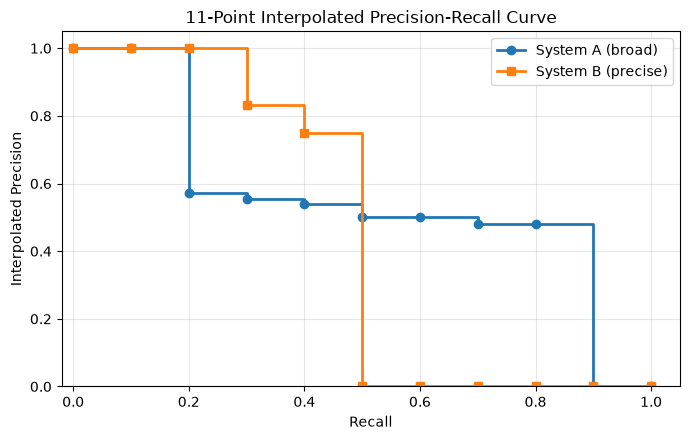

In [14]:
# Plot both interpolated curves
fig, ax = plt.subplots(figsize=(7, 4.5))

ax.step(recall_levels, interp_prec_a, where="post", marker="o",
        label="System A (broad)", linewidth=2)
ax.step(recall_levels, interp_prec_b, where="post", marker="s",
        label="System B (precise)", linewidth=2)

ax.set_xlabel("Recall")
ax.set_ylabel("Interpolated Precision")
ax.set_title("11-Point Interpolated Precision-Recall Curve")
ax.set_xlim(-0.02, 1.05)
ax.set_ylim(0, 1.05)
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [15]:
display_md(
    "**Reading the curve:** System B dominates at low recall (its first "
    "few results are highly precise) but stops early because it retrieved "
    "only 8 documents. System A continues to find relevant documents at "
    "higher recall levels, though at lower precision."
)

**Reading the curve:** System B dominates at low recall (its first few results are highly precise) but stops early because it retrieved only 8 documents. System A continues to find relevant documents at higher recall levels, though at lower precision.

---
## 4. MAP: Averaging Across Multiple Queries

A single query can be misleading. **Mean Average Precision (MAP)** averages AP
across all information needs to measure overall system quality.

In [16]:
# Compute AP for each information need
all_needs = need_ids()

rows = []
ap_values_a = []
ap_values_b = []

for need in all_needs:
    ap_a = average_precision(run(need, "A"), need)
    ap_b = average_precision(run(need, "B"), need)
    ap_values_a.append(ap_a)
    ap_values_b.append(ap_b)
    rows.append([need, need_text(need)[:50], f"{ap_a:.4f}", f"{ap_b:.4f}"])

print_table(rows, headers=["Need ID", "Question", "AP (A)", "AP (B)"])

| Need ID        | Question                                           |   AP (A) |   AP (B) |
|:---------------|:---------------------------------------------------|---------:|---------:|
| cs-foundations | Which books give a beginning master's student soli |   0.4733 |   0.3589 |
| stage-plays    | Which works in the collection are stage plays?     |   0.5867 |   0.6    |
| atwood         | Which books were written by Margaret Atwood?       |   0.8333 |   1      |
| russian-novels | Which nineteenth-century Russian novels does the l |   0      |   1      |

In [17]:
# Mean Average Precision
map_a = sum(ap_values_a) / len(ap_values_a)
map_b = sum(ap_values_b) / len(ap_values_b)

display_md(
    f"**Mean Average Precision:**\n\n"
    f"| System | MAP |\n"
    f"|--------|-----|\n"
    f"| A | {map_a:.4f} |\n"
    f"| B | {map_b:.4f} |\n\n"
    f"Notice how the 'russian-novels' need (where System A finds zero "
    f"relevant documents) drags its MAP down significantly."
)

**Mean Average Precision:**

| System | MAP |
|--------|-----|
| A | 0.4733 |
| B | 0.7397 |

Notice how the 'russian-novels' need (where System A finds zero relevant documents) drags its MAP down significantly.

---
## 5. nDCG: Graded Relevance

Binary relevance treats all relevant documents equally. But a textbook with
grade 3 (core foundations) is far more valuable than one with grade 1
(peripheral). **Normalized Discounted Cumulative Gain (nDCG)** uses graded
judgments and penalizes relevant documents placed at lower ranks.

### Step 1: Cumulative Gain (CG)

CG simply sums the relevance grades in the result list, ignoring rank.

In [18]:
# Show grades for System A's top results
run_a = run("cs-foundations", "A")

rows = []
cg = 0
for rank, doc_id in enumerate(run_a[:10], 1):
    g = grade(doc_id)
    cg += g
    rows.append([rank, record(doc_id)["title"][:40], g, cg])

print_table(rows, headers=["Rank", "Title", "Grade", "CG"])

|   Rank | Title                                    |   Grade |   CG |
|-------:|:-----------------------------------------|--------:|-----:|
|      1 | Computer Organization and Design: The Ha |       1 |    1 |
|      2 | Operating System Concepts                |       2 |    3 |
|      3 | The Handmaid's Tale                      |       0 |    3 |
|      4 | Narrative of the Life of Frederick Dougl |       0 |    3 |
|      5 | Towards a New Architecture               |       0 |    3 |
|      6 | Data Science from Scratch                |       3 |    6 |
|      7 | Concepts of Programming Languages        |       2 |    8 |
|      8 | Leaves of Grass                          |       0 |    8 |
|      9 | Artificial Intelligence: A Modern Approa |       2 |   10 |
|     10 | Ragtime                                  |       0 |   10 |

### Step 2: Discounted Cumulative Gain (DCG)

DCG applies a logarithmic discount: documents at lower ranks contribute less.

DCG@k = sum(grade_i / log2(i + 1)) for i = 1..k

In [19]:
def dcg_at_k(ranked_list, k, need="cs-foundations"):
    """DCG@k using the logarithmic discount formula."""
    dcg = 0.0
    for i, doc_id in enumerate(ranked_list[:k], 1):
        g = grade(doc_id, need)
        discount = math.log2(i + 1)
        dcg += g / discount
    return dcg

# Show step-by-step DCG computation for System A
rows = []
dcg_running = 0.0
for i, doc_id in enumerate(run_a[:10], 1):
    g = grade(doc_id)
    discount = math.log2(i + 1)
    gain = g / discount
    dcg_running += gain
    rows.append([i, record(doc_id)["title"][:35], g, f"{discount:.3f}", f"{gain:.4f}", f"{dcg_running:.4f}"])

print_table(rows, headers=["Rank", "Title", "Grade", "log2(i+1)", "Gain/Disc.", "DCG"])

|   Rank | Title                               |   Grade |   log2(i+1) |   Gain/Disc. |    DCG |
|-------:|:------------------------------------|--------:|------------:|-------------:|-------:|
|      1 | Computer Organization and Design: T |       1 |       1     |       1      | 1      |
|      2 | Operating System Concepts           |       2 |       1.585 |       1.2619 | 2.2619 |
|      3 | The Handmaid's Tale                 |       0 |       2     |       0      | 2.2619 |
|      4 | Narrative of the Life of Frederick  |       0 |       2.322 |       0      | 2.2619 |
|      5 | Towards a New Architecture          |       0 |       2.585 |       0      | 2.2619 |
|      6 | Data Science from Scratch           |       3 |       2.807 |       1.0686 | 3.3305 |
|      7 | Concepts of Programming Languages   |       2 |       3     |       0.6667 | 3.9971 |
|      8 | Leaves of Grass                     |       0 |       3.17  |       0      | 3.9971 |
|      9 | Artificial Intelligence: A Modern A |       2 |       3.322 |       0.6021 | 4.5992 |
|     10 | Ragtime                             |       0 |       3.459 |       0      | 4.5992 |

### Step 3: Ideal DCG (IDCG) and Normalization

The ideal ranking places documents in decreasing order of relevance grade.
nDCG = DCG / IDCG, producing a score between 0 and 1.

In [20]:
def ndcg_at_k(ranked_list, k, need="cs-foundations"):
    """Normalized DCG at rank k."""
    # Ideal ranking: sort all documents by grade descending
    all_grades_sorted = sorted(grades(need).values(), reverse=True)
    # Pad with zeros if needed
    while len(all_grades_sorted) < k:
        all_grades_sorted.append(0)

    idcg = 0.0
    for i, g in enumerate(all_grades_sorted[:k], 1):
        idcg += g / math.log2(i + 1)

    dcg = dcg_at_k(ranked_list, k, need)
    return dcg / idcg if idcg > 0 else 0.0

# Show IDCG computation
ideal_grades = sorted(grades().values(), reverse=True)
rows = []
idcg_running = 0.0
for i, g in enumerate(ideal_grades[:10], 1):
    discount = math.log2(i + 1)
    gain = g / discount
    idcg_running += gain
    rows.append([i, g, f"{discount:.3f}", f"{gain:.4f}", f"{idcg_running:.4f}"])

print_table(rows, headers=["Rank", "Ideal Grade", "log2(i+1)", "Gain/Disc.", "IDCG"])

|   Rank |   Ideal Grade |   log2(i+1) |   Gain/Disc. |    IDCG |
|-------:|--------------:|------------:|-------------:|--------:|
|      1 |             3 |       1     |       3      |  3      |
|      2 |             3 |       1.585 |       1.8928 |  4.8928 |
|      3 |             3 |       2     |       1.5    |  6.3928 |
|      4 |             2 |       2.322 |       0.8614 |  7.2541 |
|      5 |             2 |       2.585 |       0.7737 |  8.0278 |
|      6 |             2 |       2.807 |       0.7124 |  8.7403 |
|      7 |             2 |       3     |       0.6667 |  9.4069 |
|      8 |             1 |       3.17  |       0.3155 |  9.7224 |
|      9 |             1 |       3.322 |       0.301  | 10.0234 |
|     10 |             1 |       3.459 |       0.2891 | 10.3125 |

In [21]:
# Compare nDCG at various cutoffs
run_b = run("cs-foundations", "B")

rows = []
for k in [3, 5, 8, 10, 15]:
    ndcg_a = ndcg_at_k(run_a, k)
    ndcg_b = ndcg_at_k(run_b, k) if k <= len(run_b) else ndcg_at_k(run_b + [""] * (k - len(run_b)), k)
    rows.append([k, f"{ndcg_a:.4f}", f"{ndcg_b:.4f}"])

print_table(rows, headers=["k", "nDCG@k (System A)", "nDCG@k (System B)"])

|   k |   nDCG@k (System A) |   nDCG@k (System B) |
|----:|--------------------:|--------------------:|
|   3 |              0.3538 |              0.8436 |
|   5 |              0.2818 |              0.7681 |
|   8 |              0.4111 |              0.8049 |
|  10 |              0.446  |              0.7588 |
|  15 |              0.5103 |              0.6728 |

In [22]:
display_md(
    "**Interpretation:** System B places high-grade documents (grade 3) "
    "at the very top of its ranking, giving it excellent nDCG at early cutoffs. "
    "System A scatters its high-grade documents across many ranks, reducing "
    "its discounted gain.\n\n"
    "nDCG captures something that binary metrics miss: not just *whether* "
    "a relevant document was found, but *how relevant* it was and *where* it appeared."
)

**Interpretation:** System B places high-grade documents (grade 3) at the very top of its ranking, giving it excellent nDCG at early cutoffs. System A scatters its high-grade documents across many ranks, reducing its discounted gain.

nDCG captures something that binary metrics miss: not just *whether* a relevant document was found, but *how relevant* it was and *where* it appeared.

---
## Summary: Choosing the Right Metric

In [23]:
print_table(
    [
        ["Precision / Recall", "Unranked set", "Simple filtering tasks"],
        ["F-measure", "Unranked set", "Single-number set quality; beta tunes emphasis"],
        ["P@k", "Top-k results", "Voice assistants (P@1), search result pages (P@10)"],
        ["Reciprocal Rank", "First relevant", "Navigational queries, question answering"],
        ["Average Precision", "Full ranking", "Research search, document discovery"],
        ["MAP", "Multiple queries", "Overall system comparison across a test set"],
        ["nDCG", "Graded relevance", "When documents vary in usefulness (web, enterprise)"],
    ],
    headers=["Metric", "Evaluates", "Best For"],
)

| Metric             | Evaluates        | Best For                                            |
|:-------------------|:-----------------|:----------------------------------------------------|
| Precision / Recall | Unranked set     | Simple filtering tasks                              |
| F-measure          | Unranked set     | Single-number set quality; beta tunes emphasis      |
| P@k                | Top-k results    | Voice assistants (P@1), search result pages (P@10)  |
| Reciprocal Rank    | First relevant   | Navigational queries, question answering            |
| Average Precision  | Full ranking     | Research search, document discovery                 |
| MAP                | Multiple queries | Overall system comparison across a test set         |
| nDCG               | Graded relevance | When documents vary in usefulness (web, enterprise) |

In [24]:
display_md(
    "**Key takeaway:** No single metric captures all aspects of retrieval quality. "
    "Metric choice depends on the application: P@1 for voice assistants, "
    "MAP for exhaustive research, nDCG when relevance is graded."
)

**Key takeaway:** No single metric captures all aspects of retrieval quality. Metric choice depends on the application: P@1 for voice assistants, MAP for exhaustive research, nDCG when relevance is graded.

---
## Try It Yourself

1. **Change the cutoff:** Compute nDCG@3 for both systems. Which one wins at very shallow depths?
2. **New need:** Compute AP for the "stage-plays" need. Does System A or B do better?
3. **F-beta exploration:** At what beta value do Systems A and B produce equal F-scores?
4. **Design your own system:** Rearrange System A's results to maximize AP. What is the theoretical maximum?

In [25]:
# Starter code: compute AP for a different need
need = "stage-plays"
ap_a_plays = average_precision(run(need, "A"), need)
ap_b_plays = average_precision(run(need, "B"), need)

display_md(
    f"**AP for '{need}' need:**\n\n"
    f"- System A: {ap_a_plays:.4f}\n"
    f"- System B: {ap_b_plays:.4f}"
)

**AP for 'stage-plays' need:**

- System A: 0.5867
- System B: 0.6000